# Censored Data HAL Density Estimation

This notebook demonstrates HAL-based density estimation for right-censored data on [0,1], following the workflow from the original research notebooks but using the refactored `haldensity.censoring` subpackage.

## Overview

For right-censored data where we observe `(T, Δ)` with:
- `T = min(X, C)` (observed time)
- `Δ = I(X ≤ C)` (event indicator)

We implement:
1. **IPCW-HAL-MLE**: Inverse probability of censoring weighted HAL on uncensored observations
2. **EM-IPCW-HAL-MLE**: Expectation-Maximization with multiple imputation for the censored observations
3. **Optuna-based hyperparameter selection**: Cross-validated lambda/norm_constraint tuning

## Sections
1. Data Simulation (Truncated Normal)
2. Kaplan-Meier Censoring Survival Estimation
3. IPCW-HAL-MLE Initialization
4. EM-IPCW-HAL-MLE with Multiple Imputation
5. Hyperparameter Tuning with Optuna
6. Comparison and Evaluation (KL divergence, incomplete-data log-likelihood)


In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import truncnorm

# HALDensity censored-data subpackage
from haldensity.censoring import (
    KaplanMeier,
    compute_ipcw_weights,
    WeightedCVXPYEstimator,
    EMIPCWEstimator,
    CensoredOptunaHyperparameterTuner,
    pipelines,
    kl_divergence,
    incomplete_loglik,
    mi_complete_loglik,
)

print("✓ Imports successful")


✓ Imports successful


/Users/zzp/Desktop/Github/HALDensity/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data Simulation

Generate right-censored data from a truncated normal distribution on [0,1]:
- True event times `X ~ TruncatedNormal(μ=0.5, σ=0.1, support=[0,1])`
- Censoring times `C ~ Uniform(0,1)`
- Observed: `T = min(X, C)` and `Δ = I(X ≤ C)`


In [2]:
# Simulation parameters
np.random.seed(42)
rng = np.random.default_rng(42)

n_samples = 1000
mean, std = 0.5, 0.1
lower, upper = 0.0, 1.0

# Generate truncated normal event times
a, b = (lower - mean) / std, (upper - mean) / std
X_true = truncnorm.rvs(a, b, loc=mean, scale=std, size=n_samples, random_state=rng)

# Generate uniform censoring times
C = rng.uniform(lower, upper, size=n_samples)

# Observed data
T = np.minimum(X_true, C)
Delta = (X_true <= C).astype(int)

# Store in DataFrame
data = pd.DataFrame({"T": T, "Delta": Delta})

print(f"Sample size: {n_samples}")
print(f"Censoring rate: {(1 - Delta.mean()):.1%}")
print(f"Observed events: {Delta.sum()}")
print(f"Censored observations: {(1 - Delta).sum()}")


Sample size: 1000
Censoring rate: 49.8%
Observed events: 502
Censored observations: 498


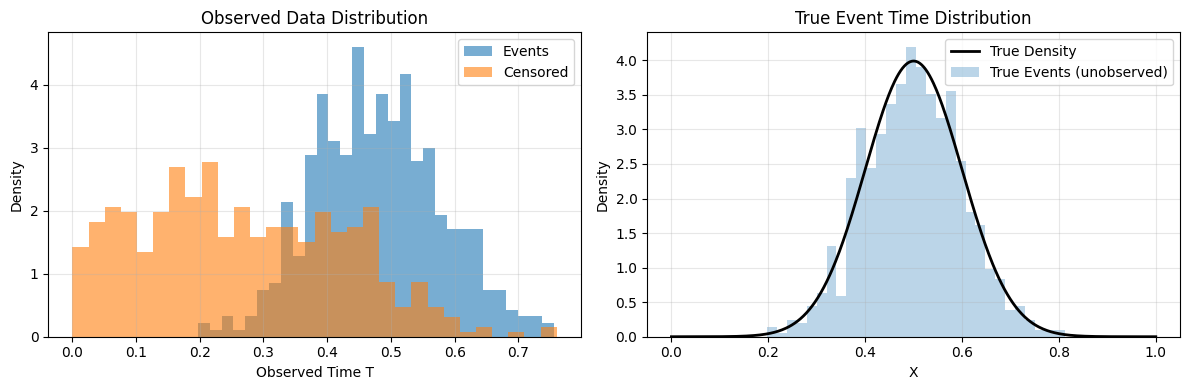

In [3]:
# Visualize observed data
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of observed times
axes[0].hist(data.loc[data['Delta'] == 1, 'T'], bins=30, alpha=0.6, label='Events', density=True)
axes[0].hist(data.loc[data['Delta'] == 0, 'T'], bins=30, alpha=0.6, label='Censored', density=True)
axes[0].set_xlabel('Observed Time T')
axes[0].set_ylabel('Density')
axes[0].set_title('Observed Data Distribution')
axes[0].legend()
axes[0].grid(alpha=0.3)

# True density
grid = np.linspace(0, 1, 500)
true_density = truncnorm.pdf(grid, a, b, loc=mean, scale=std)
axes[1].plot(grid, true_density, 'k-', linewidth=2, label='True Density')
axes[1].hist(X_true, bins=30, alpha=0.3, density=True, label='True Events (unobserved)')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Density')
axes[1].set_title('True Event Time Distribution')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 2. Kaplan-Meier Censoring Survival Estimation

Estimate the censoring survival function $S_c(t) = P(C > t)$ using Kaplan-Meier on the censoring process.


In [4]:
# Fit Kaplan-Meier for censoring survival
km = KaplanMeier()
km.fit(data, time_col="T", delta_col="Delta")

# Get step function
km_times, km_surv = km.stepwise_survival_()

print(f"KM estimated at {len(km_times)} unique time points")
print(f"S_c(0) = {km.predict(0.0):.3f}")
print(f"S_c(0.5) = {km.predict(0.5):.3f}")
print(f"S_c(1.0) = {km.predict(1.0):.3f}")


KM estimated at 1000 unique time points
S_c(0) = 1.000
S_c(0.5) = 0.490
S_c(1.0) = 0.000


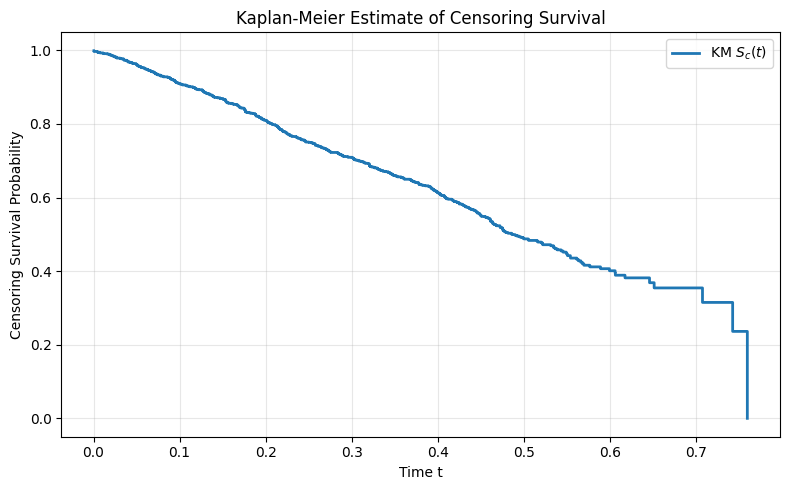


IPCW weights: min=0.00, max=4.23, mean=1.00
Non-zero weights (events): 502


In [5]:
# Plot KM censoring survival
plt.figure(figsize=(8, 5))
plt.step(km_times, km_surv, where='post', linewidth=2, label='KM $S_c(t)$')
plt.xlabel('Time t')
plt.ylabel('Censoring Survival Probability')
plt.title('Kaplan-Meier Estimate of Censoring Survival')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Compute IPCW weights
ipcw_weights = compute_ipcw_weights(
    T=data["T"].values,
    Delta=data["Delta"].values,
    S_c_predict=km.predict,
)

print(f"\nIPCW weights: min={ipcw_weights.min():.2f}, max={ipcw_weights.max():.2f}, mean={ipcw_weights.mean():.2f}")
print(f"Non-zero weights (events): {(ipcw_weights > 0).sum()}")


## 3. IPCW-HAL-MLE Initialization

Fit a weighted HAL density estimator using only the uncensored observations with IPCW weights. This provides a baseline and initialization for the EM algorithm.


In [6]:
# Fit IPCW-weighted HAL estimator (order 0)
# First compute KM and IPCW weights manually for WeightedCVXPYEstimator
km_for_ipcw = KaplanMeier()
km_for_ipcw.fit(data, time_col="T", delta_col="Delta")

ipcw_weights_all = compute_ipcw_weights(
    T=data["T"].values,
    Delta=data["Delta"].values,
    S_c_predict=km_for_ipcw.predict,
)

# Create DataFrame with W1 column for uncensored observations only
uncensored_mask = data["Delta"] == 1
ipcw_data = pd.DataFrame({"W1": data.loc[uncensored_mask, "T"].values})
ipcw_weights = ipcw_weights_all[uncensored_mask]

# Fit the weighted estimator
ipcw_estimator = WeightedCVXPYEstimator(
    norm_constraint=8.0,
    basis_order=0,
    solver="ECOS",
)
ipcw_estimator.fit(ipcw_data, sample_weights=ipcw_weights)

# Get results
ipcw_results = ipcw_estimator.get_results()
print(f"IPCW-HAL knots selected: {len(ipcw_results['grid_points_hal_selected'])}")
print(f"IPCW-HAL coefficients: {ipcw_results['theta_hat'].shape}")

# Evaluate on grid
eval_grid = np.linspace(0, 1, 500)
ipcw_density = ipcw_estimator.get_density_at_points(eval_grid)

# Compute incomplete-data log-likelihood
ipcw_ll = incomplete_loglik(ipcw_estimator, data, time_col="T", delta_col="Delta")
print(f"IPCW incomplete-data log-likelihood: {ipcw_ll:.4f}")

# Compute KL divergence from true density
ipcw_kl = kl_divergence(
    true_pdf_fn=lambda x: truncnorm.pdf(x, a, b, loc=mean, scale=std),
    grid=eval_grid,
    est_density=ipcw_density,
)
print(f"IPCW KL divergence: {ipcw_kl:.6f}")


IPCW-HAL knots selected: 382
IPCW-HAL coefficients: (505,)
IPCW incomplete-data log-likelihood: 325.1318
IPCW KL divergence: 0.036436


/Users/zzp/Desktop/Github/HALDensity/.venv/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


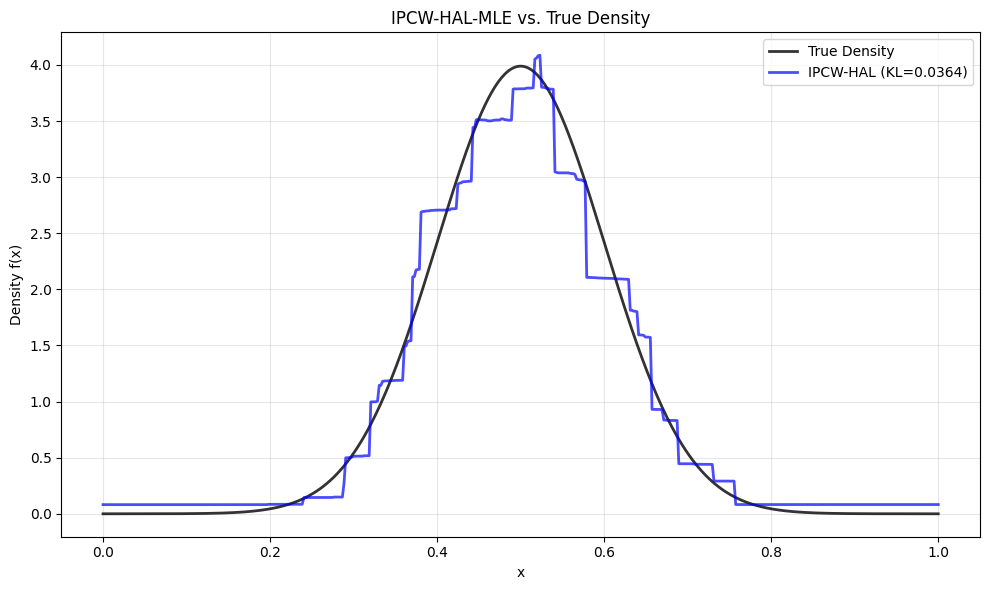

In [7]:
# Plot IPCW estimate vs. true density
plt.figure(figsize=(10, 6))
plt.plot(grid, true_density, 'k-', linewidth=2, label='True Density', alpha=0.8)
plt.plot(eval_grid, ipcw_density, 'b-', linewidth=2, label=f'IPCW-HAL (KL={ipcw_kl:.4f})', alpha=0.7)
plt.xlabel('x')
plt.ylabel('Density f(x)')
plt.title('IPCW-HAL-MLE vs. True Density')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 4. EM-IPCW-HAL-MLE with Multiple Imputation

Run the Expectation-Maximization algorithm with multiple imputation:
- **E-step**: Impute censored observations from the current density estimate
- **M-step**: Fit weighted HAL on the augmented pseudo-complete data

This iteratively refines the density estimate by incorporating information from censored observations.


In [8]:
# Fit EM-IPCW-HAL estimator (order 0)
em_estimator = EMIPCWEstimator(
    norm_constraint=8.0,
    m_step_norm_constraint=8.0 * 1.0,
    m_imputations=30,
    max_em_iter=10,
    em_tol=1e-4,
    basis_order=0,
    init_solver="ECOS",
    m_step_solver="ECOS",
    rng_seed=42,
)
em_estimator.fit(data)

# Get results
em_results = em_estimator.get_results()
print(f"EM iterations: {em_results['em_iterations']}")
print(f"EM converged: {em_results['em_converged']}")
print(f"EM-HAL knots selected: {len(em_results['grid_points_hal_selected'])}")

# Evaluate on grid
em_density = em_estimator.get_density_at_points(eval_grid)

# Compute incomplete-data log-likelihood
em_ll = incomplete_loglik(em_estimator, data, time_col="T", delta_col="Delta")
print(f"EM incomplete-data log-likelihood: {em_ll:.4f}")

# Compute KL divergence
em_kl = kl_divergence(
    true_pdf_fn=lambda x: truncnorm.pdf(x, a, b, loc=mean, scale=std),
    grid=eval_grid,
    est_density=em_density,
)
print(f"EM KL divergence: {em_kl:.6f}")

# Compare with IPCW
print(f"\nImprovement over IPCW:")
print(f"  ΔLL = {em_ll - ipcw_ll:.4f}")
print(f"  ΔKL = {em_kl - ipcw_kl:.6f} (negative is better)")


EM iterations: 10
EM converged: False
EM-HAL knots selected: 30
EM incomplete-data log-likelihood: 312.6747
EM KL divergence: 0.059016

Improvement over IPCW:
  ΔLL = -12.4572
  ΔKL = 0.022579 (negative is better)


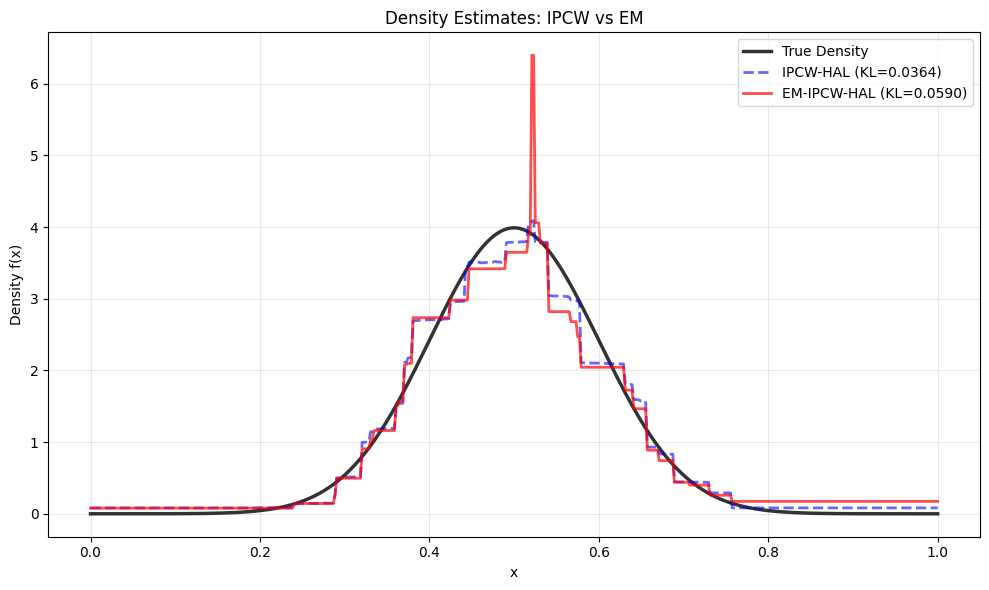

In [9]:
# Plot comparison: IPCW vs EM vs True
plt.figure(figsize=(10, 6))
plt.plot(grid, true_density, 'k-', linewidth=2.5, label='True Density', alpha=0.8)
plt.plot(eval_grid, ipcw_density, 'b--', linewidth=2, label=f'IPCW-HAL (KL={ipcw_kl:.4f})', alpha=0.6)
plt.plot(eval_grid, em_density, 'r-', linewidth=2, label=f'EM-IPCW-HAL (KL={em_kl:.4f})', alpha=0.7)
plt.xlabel('x')
plt.ylabel('Density f(x)')
plt.title('Density Estimates: IPCW vs EM')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Hyperparameter Tuning with Optuna

Use Bayesian optimization (Optuna) to select the optimal `norm_constraint` (lambda) and other hyperparameters via cross-validation on the incomplete-data log-likelihood.


In [10]:
# Configure Optuna tuner for EM estimator
tuner = CensoredOptunaHyperparameterTuner(
    estimator_name="EMIPCWEstimator",
    data=data,
    cv_folds=5,
    metric="incomplete",  # incomplete-data log-likelihood; alternative: "mi_complete"
    param_overrides={
        "basis_order": [0],  # Fix to order 0 for demo
        "norm_constraint": {"low": 1, "high": 50, "log": True},
        "m_imputations": 20,
        "max_em_iter": 10,
    },
    random_state=42,
    silent=False,
)

# Run optimization
print("Running Optuna hyperparameter tuning...")
tuner.optimize(n_trials=10)

# Get best parameters
best_params = tuner.best_params
print(f"\nBest hyperparameters:")
for key, val in best_params.items():
    print(f"  {key}: {val}")
print(f"Best CV score: {tuner.best_metric_value:.4f}")


Running Optuna hyperparameter tuning...


Censored Optuna: 100%|██████████| 10/10 [03:57<00:00, 23.72s/trial, metric=-2804.313, best=59.026, order=0] 

Best params: {'basis_order': 0, 'norm_constraint': 5.027688333063851, 'm_step_norm_multiplier': 1.538725831313009}
Best metric: 59.02552488038384

Best hyperparameters:
  basis_order: 0
  norm_constraint: 5.027688333063851
  m_step_norm_multiplier: 1.538725831313009
Best CV score: 59.0255


In [11]:
# Fit final model with best parameters on full data
print("\nFitting final model with best hyperparameters...")
tuned_estimator = tuner.fit_best_model()

# Evaluate tuned model
tuned_density = tuned_estimator.get_density_at_points(eval_grid)
tuned_ll = incomplete_loglik(tuned_estimator, data, time_col="T", delta_col="Delta")
tuned_kl = kl_divergence(
    true_pdf_fn=lambda x: truncnorm.pdf(x, a, b, loc=mean, scale=std),
    grid=eval_grid,
    est_density=tuned_density,
)

print(f"Tuned model incomplete-data log-likelihood: {tuned_ll:.4f}")
print(f"Tuned model KL divergence: {tuned_kl:.6f}")



Fitting final model with best hyperparameters...
Tuned model incomplete-data log-likelihood: 319.8914
Tuned model KL divergence: 0.052998


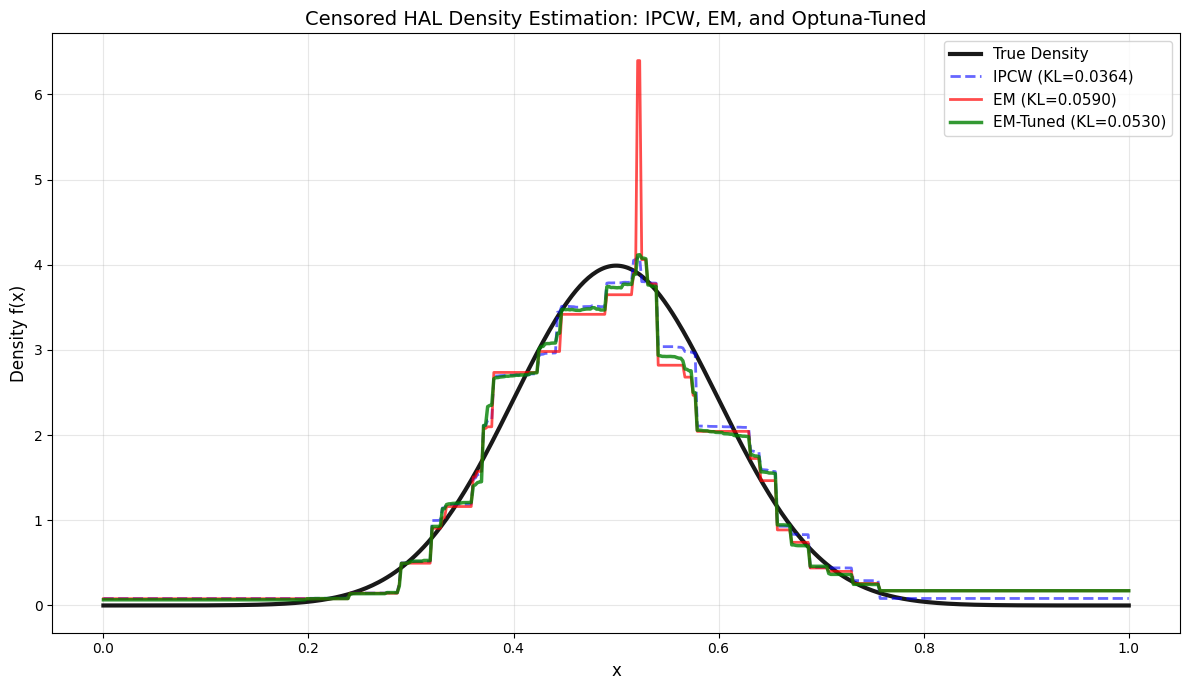

In [12]:
# Plot all estimates
plt.figure(figsize=(12, 7))
plt.plot(grid, true_density, 'k-', linewidth=3, label='True Density', alpha=0.9)
plt.plot(eval_grid, ipcw_density, 'b--', linewidth=2, label=f'IPCW (KL={ipcw_kl:.4f})', alpha=0.6)
plt.plot(eval_grid, em_density, 'r-', linewidth=2, label=f'EM (KL={em_kl:.4f})', alpha=0.7)
plt.plot(eval_grid, tuned_density, 'g-', linewidth=2.5, label=f'EM-Tuned (KL={tuned_kl:.4f})', alpha=0.8)
plt.xlabel('x', fontsize=12)
plt.ylabel('Density f(x)', fontsize=12)
plt.title('Censored HAL Density Estimation: IPCW, EM, and Optuna-Tuned', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Testing Different Basis Orders

HALDensity supports different polynomial orders for the basis functions:
- **Order 0**: Step functions (indicators) $\{1, I(x \geq \xi_1), ..., I(x \geq \xi_m)\}$
- **Order 1**: Linear splines $\{1, x, (x-\xi_1)_+, ..., (x-\xi_m)_+\}$
- **Order 2**: Quadratic splines $\{1, x, x^2, (x-\xi_1)_+^2, ..., (x-\xi_m)_+^2\}$

Let's compare performance across different orders.


In [13]:
# Compare different basis orders
orders = [0, 1, 2]
norm_constraints = [6.0, 80.0, 550.0]
order_results = {}

for order, norm_constraint in zip(orders, norm_constraints):
    print(f"\n{'='*60}")
    print(f"Fitting EM-IPCW-HAL with basis_order={order} and norm_constraint={norm_constraint}")
    print('='*60)
    
    est = EMIPCWEstimator(
        norm_constraint=norm_constraint,
        m_imputations=25,
        max_em_iter=8,
        basis_order=order,
        init_solver="ECOS",
        m_step_solver="ECOS",
        rng_seed=42,
    )
    est.fit(data)
    
    # Evaluate
    density = est.get_density_at_points(eval_grid)
    ll = incomplete_loglik(est, data, time_col="T", delta_col="Delta")
    kl = kl_divergence(
        true_pdf_fn=lambda x: truncnorm.pdf(x, a, b, loc=mean, scale=std),
        grid=eval_grid,
        est_density=density,
    )
    
    order_results[order] = {
        "estimator": est,
        "density": density,
        "log_likelihood": ll,
        "kl_divergence": kl,
        "n_knots": len(est.get_results()["grid_points_hal_selected"]),
        "em_iters": est.get_results()["em_iterations"],
    }
    
    print(f"Order {order}: LL={ll:.4f}, KL={kl:.6f}, knots={order_results[order]['n_knots']}, EM iters={order_results[order]['em_iters']}")



Fitting EM-IPCW-HAL with basis_order=0 and norm_constraint=6.0
Order 0: LL=306.9788, KL=0.081240, knots=24, EM iters=8

Fitting EM-IPCW-HAL with basis_order=1 and norm_constraint=80.0
Order 1: LL=341.1196, KL=0.005550, knots=59, EM iters=8

Fitting EM-IPCW-HAL with basis_order=2 and norm_constraint=550.0
Order 2: LL=339.8750, KL=0.003519, knots=476, EM iters=8


In [14]:
# Create comparison table
comparison_df = pd.DataFrame({
    "Order": orders,
    "Log-Likelihood": [order_results[o]["log_likelihood"] for o in orders],
    "KL Divergence": [order_results[o]["kl_divergence"] for o in orders],
    "Knots": [order_results[o]["n_knots"] for o in orders],
    "EM Iterations": [order_results[o]["em_iters"] for o in orders],
})
print("\n" + "="*70)
print("Basis Order Comparison")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)



Basis Order Comparison
 Order  Log-Likelihood  KL Divergence  Knots  EM Iterations
     0      306.978753       0.081240     24              8
     1      341.119606       0.005550     59              8
     2      339.874985       0.003519    476              8


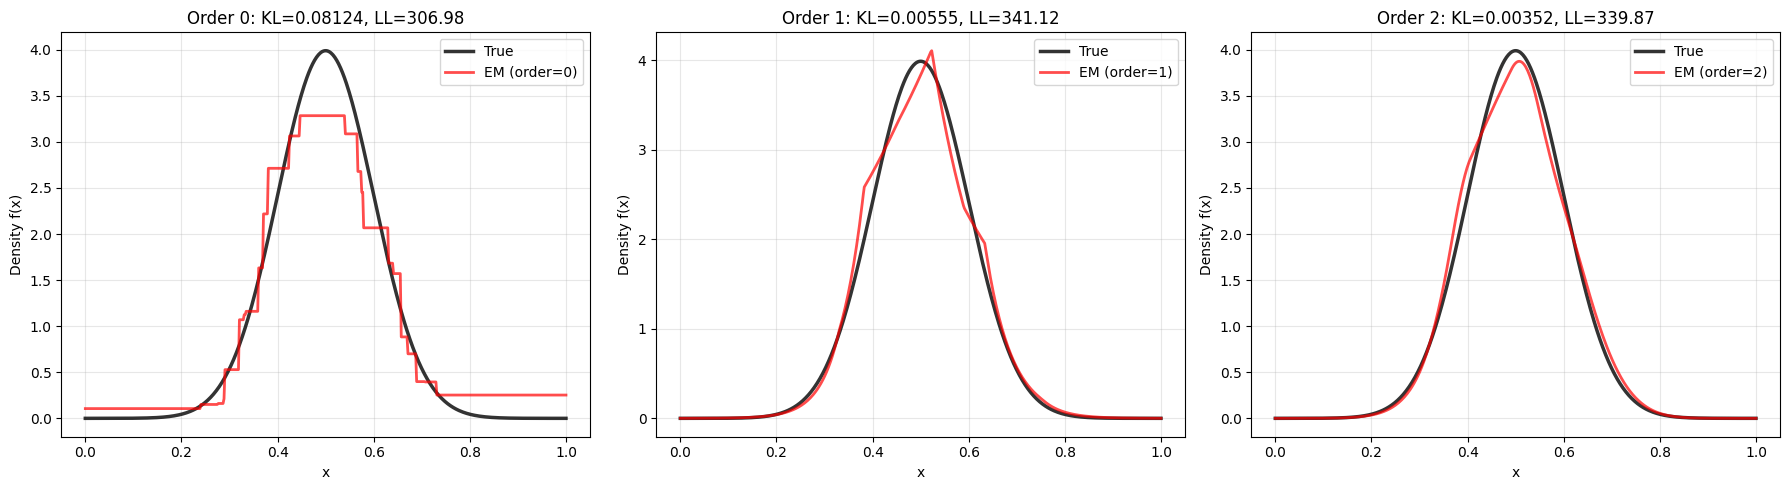

In [15]:
# Plot densities for different orders
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, order in enumerate(orders):
    ax = axes[idx]
    res = order_results[order]
    
    ax.plot(grid, true_density, 'k-', linewidth=2.5, label='True', alpha=0.8)
    ax.plot(eval_grid, res["density"], 'r-', linewidth=2, label=f'EM (order={order})', alpha=0.7)
    ax.set_xlabel('x')
    ax.set_ylabel('Density f(x)')
    ax.set_title(f'Order {order}: KL={res["kl_divergence"]:.5f}, LL={res["log_likelihood"]:.2f}')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 7. Using Pipeline Convenience Functions

The `haldensity.censoring.pipelines` module provides convenience functions for quick execution.


In [16]:
# Use pipeline for IPCW-HAL-MLE
print("Running IPCW-HAL-MLE pipeline...")
ipcw_pipeline_results, ipcw_pipeline_est = pipelines.run_ipcw_hal_mle(
    data=data,
    norm_constraint=550.0,
    basis_order=2,
    return_estimator=True,
)
print(f"IPCW pipeline completed: {len(ipcw_pipeline_results['grid_points_hal_selected'])} knots")

# Use pipeline for EM-IPCW-HAL-MLE
print("\nRunning EM-IPCW-HAL-MLE pipeline...")
em_pipeline_results, em_pipeline_est = pipelines.run_em_ipcw_hal_mle(
    data=data,
    norm_constraint=550.0,
    m_imputations=30,
    max_em_iter=10,
    basis_order=2,
    return_estimator=True,
)
print(f"EM pipeline completed: {em_pipeline_results['em_iterations']} iterations, {em_pipeline_results['em_converged']} converged")
print(f"Final knots: {len(em_pipeline_results['grid_points_hal_selected'])}")


Running IPCW-HAL-MLE pipeline...
IPCW pipeline completed: 384 knots

Running EM-IPCW-HAL-MLE pipeline...
WARNING - large complementary slackness residual: 0.011566
EM pipeline completed: 9 iterations, True converged
Final knots: 460


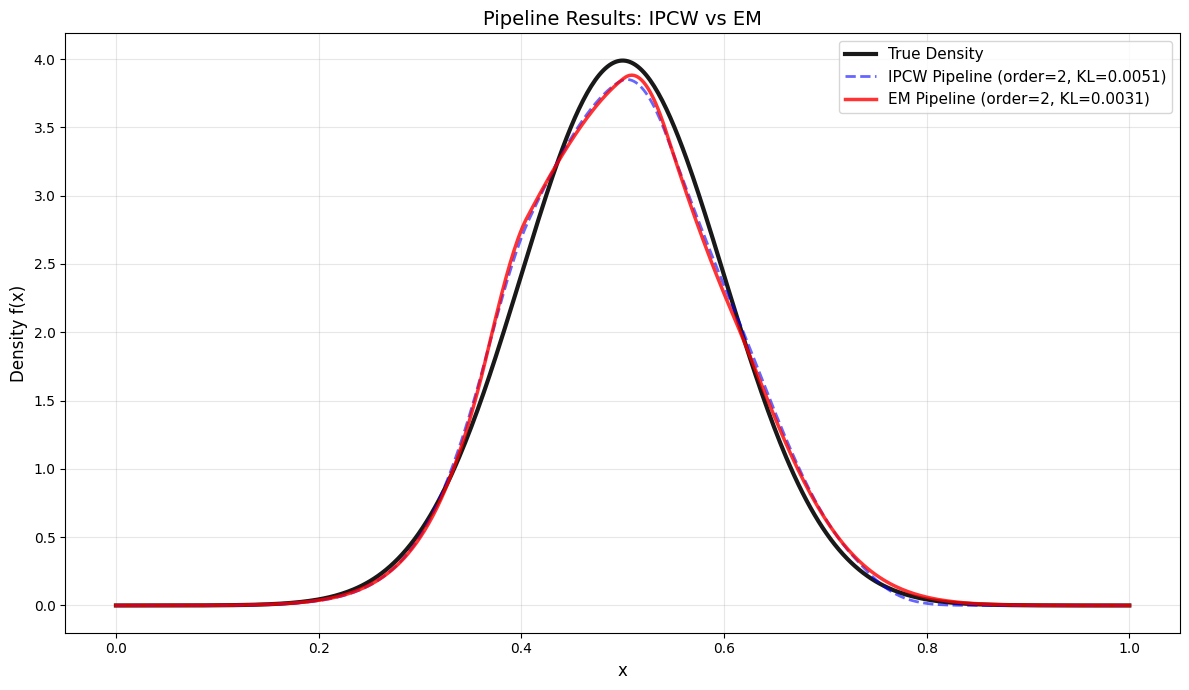


Pipeline Comparison:
IPCW: 384 knots, KL=0.005061
EM: 460 knots, 9 iters, KL=0.003065


In [17]:
# Plot pipeline results
ipcw_pipe_density = ipcw_pipeline_est.get_density_at_points(eval_grid)
em_pipe_density = em_pipeline_est.get_density_at_points(eval_grid)

ipcw_pipe_kl = kl_divergence(
    true_pdf_fn=lambda x: truncnorm.pdf(x, a, b, loc=mean, scale=std),
    grid=eval_grid,
    est_density=ipcw_pipe_density,
)
em_pipe_kl = kl_divergence(
    true_pdf_fn=lambda x: truncnorm.pdf(x, a, b, loc=mean, scale=std),
    grid=eval_grid,
    est_density=em_pipe_density,
)

plt.figure(figsize=(12, 7))
plt.plot(grid, true_density, 'k-', linewidth=3, label='True Density', alpha=0.9)
plt.plot(eval_grid, ipcw_pipe_density, 'b--', linewidth=2, 
         label=f'IPCW Pipeline (order=2, KL={ipcw_pipe_kl:.4f})', alpha=0.6)
plt.plot(eval_grid, em_pipe_density, 'r-', linewidth=2.5, 
         label=f'EM Pipeline (order=2, KL={em_pipe_kl:.4f})', alpha=0.8)
plt.xlabel('x', fontsize=12)
plt.ylabel('Density f(x)', fontsize=12)
plt.title('Pipeline Results: IPCW vs EM', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nPipeline Comparison:")
print(f"IPCW: {len(ipcw_pipeline_results['grid_points_hal_selected'])} knots, KL={ipcw_pipe_kl:.6f}")
print(f"EM: {len(em_pipeline_results['grid_points_hal_selected'])} knots, {em_pipeline_results['em_iterations']} iters, KL={em_pipe_kl:.6f}")
